## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 2. Data loading,structure and summary stats

In [10]:
df_raw = pd.read_csv("../data/raw/credit_risk_dataset.csv")
print("__"*10)
df_raw.info()
print("__"*10)
df_raw.describe()
print("__"*10)

____________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
__________

In [5]:
df_raw.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [13]:
df_raw.duplicated().sum()

np.int64(165)

1) Missing values:
- person_emp_length 32581-31686 = 895
- loan_int_rate 32581 - 29465 = 3116

2) Extreme values:
- person_age -> 144 unrealistic value
- person_emp_length -> 123 unrealistic value
- person_income -> 6000000 while mean is 60000

3) Duplicates:
- 165 count






In [11]:
df = df_raw.copy()

 I'm keeping the original `df_raw` untouched and doing all cleaning on a copy called `df`, so I can always go back and compare before/after.

## 3. Duplicates

**Decision: drop them.** A duplicate row is the exact same applicant record appearing twice — it doesn't add new information, it just double-counts one person and can quietly bias any statistic or model trained on the data.

In [12]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows found: 165
Shape after dropping duplicates: (32416, 12)


In [14]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print("Columns with missing values:")
print(missing_counts)


Columns with missing values:
person_emp_length     887
loan_int_rate        3095
dtype: int64


## 4. Missing values

**Decision: median for numeric columns, mode for categorical columns.**
Median is safer than mean here because both `person_emp_length` and `loan_int_rate` are skewed (a few very large values would drag the mean up); median isn't affected by that.


In [15]:
# person_emp_length: numeric -> fill with median
median_emp_length = df["person_emp_length"].median()
df["person_emp_length"] = df["person_emp_length"].fillna(median_emp_length)

# loan_int_rate: numeric -> fill with median
median_int_rate = df["loan_int_rate"].median()
df["loan_int_rate"] = df["loan_int_rate"].fillna(median_int_rate)

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [16]:
missing_int_rate_mask = df_raw["loan_int_rate"].isnull()
print(df_raw.loc[missing_int_rate_mask, "loan_grade"].value_counts(normalize=True))
print("---compare to overall distribution---")
print(df_raw["loan_grade"].value_counts(normalize=True))

loan_grade
B    0.338896
A    0.321887
C    0.202182
D    0.100128
E    0.026637
F    0.008665
G    0.001605
Name: proportion, dtype: float64
---compare to overall distribution---
loan_grade
A    0.330776
B    0.320770
C    0.198214
D    0.111292
E    0.029588
F    0.007397
G    0.001964
Name: proportion, dtype: float64


**A check worth doing, not just a formality:** if missing `loan_int_rate` values were concentrated in one `loan_grade` or correlated with `loan_status`, filling them with the overall median could quietly hide a pattern instead of neutrally handling randomness.
Quick sanity check below — if the missing rate looks roughly similar across grades, we're fine.

## 5. Unrealistic values (data-entry errors)

**Important distinction I'm applying here, and in every future project:**
- `person_age = 144` and `person_emp_length = 123` are **impossible** — these are data entry errors, not real extreme people. Fixing them is correcting a mistake.
- `person_income` going up to 600,000+ is **rare, but genuinely possible** — some people really do earn that much. This is *not* a mistake, so I will **not** impute or delete it. Instead, I'll handle its skew later using a log transform, only for plotting/modeling — the original values stay untouched in the data.

First, let's see exactly how many rows are affected by the impossible values, since the right fix depends on how many rows we're talking about (a handful vs a big chunk).


In [18]:
print("Rows with person_age > 100:", (df["person_age"] > 100).sum())
print("Rows with person_emp_length > 60:", (df["person_emp_length"] > 60).sum())

Rows with person_age > 100: 5
Rows with person_emp_length > 60: 2


Since this affects only a tiny number of rows, median substitution is low-risk here — if this ever turns out to be a large chunk of rows in a different project, that would be a signal to investigate further rather than just impute.


In [19]:
age_median = df.loc[df["person_age"] <= 100, "person_age"].median()
df.loc[df["person_age"] > 100, "person_age"] = age_median

emp_median = df.loc[df["person_emp_length"] <= 60, "person_emp_length"].median()
df.loc[df["person_emp_length"] > 60, "person_emp_length"] = emp_median

print("Max age now:", df["person_age"].max())
print("Max emp_length now:", df["person_emp_length"].max())


Max age now: 94
Max emp_length now: 41.0


## 6. Target distribution

`loan_status` is our target: 1 = defaulted, 0 = did not default.

/var/folders/rf/m7bft5j547d3wtc9rz_s942m0000gn/T/ipykernel_64419/1497193001.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Default (0)", "Default (1)"])


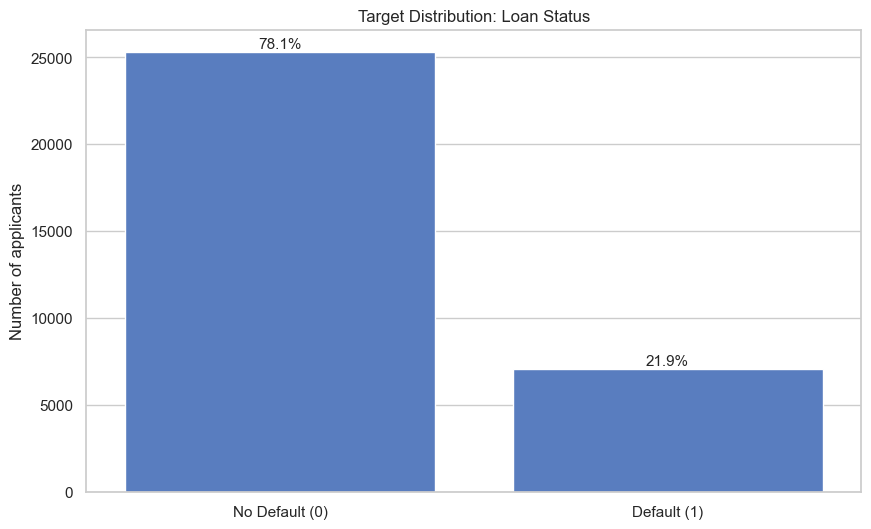

In [20]:
ax = sns.countplot(data=df, x="loan_status")
ax.set_xticklabels(["No Default (0)", "Default (1)"])
ax.set_title("Target Distribution: Loan Status")
ax.set_xlabel("")
ax.set_ylabel("Number of applicants")

for p in ax.patches:
    pct = 100 * p.get_height() / len(df)
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

## 7. Numeric distributions: before vs after cleaning

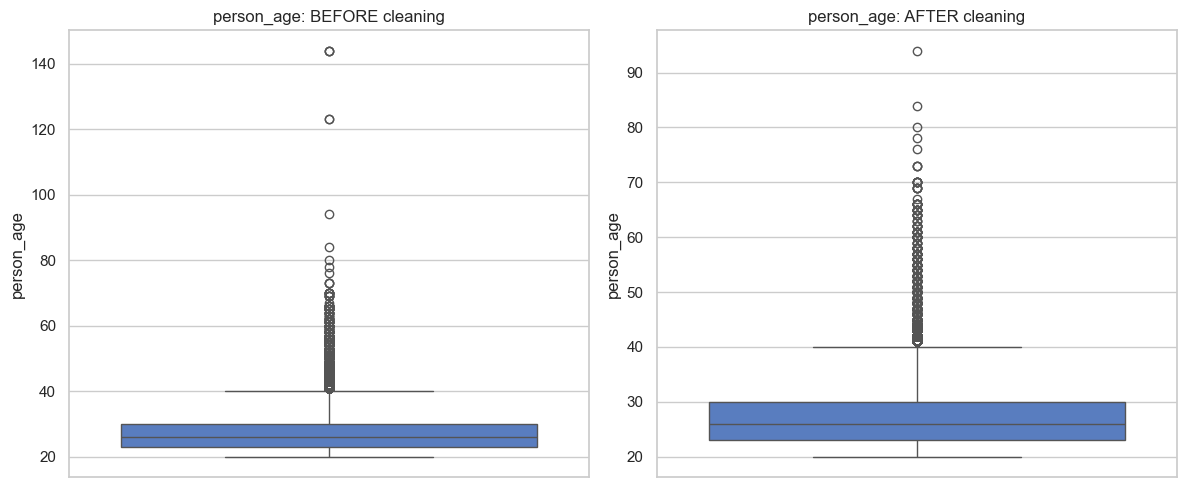

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_raw["person_age"], ax=axes[0])
axes[0].set_title("person_age: BEFORE cleaning")

sns.boxplot(y=df["person_age"], ax=axes[1])
axes[1].set_title("person_age: AFTER cleaning")

plt.tight_layout()
plt.show()

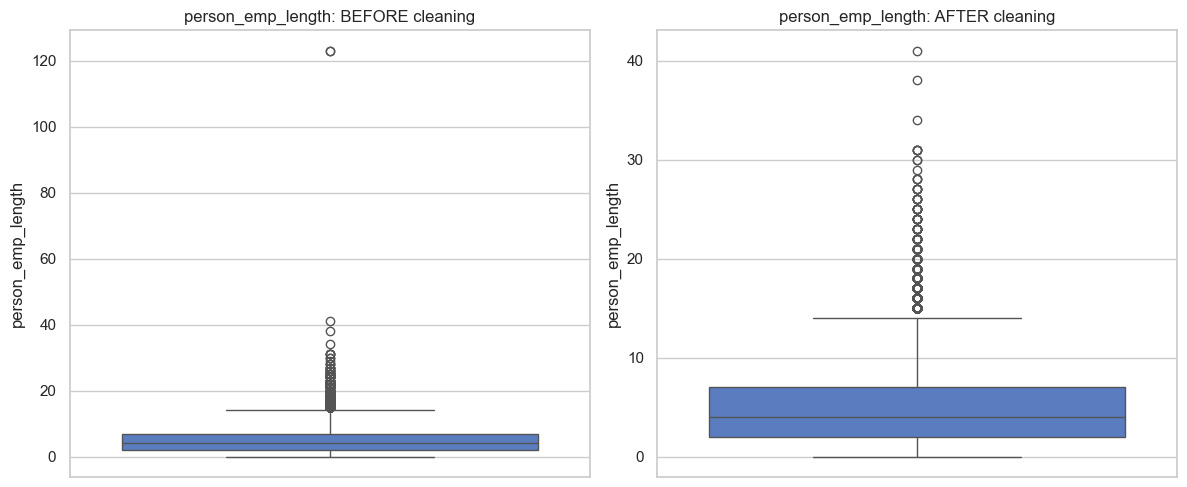

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_raw["person_emp_length"], ax=axes[0])
axes[0].set_title("person_emp_length: BEFORE cleaning")

sns.boxplot(y=df["person_emp_length"], ax=axes[1])
axes[1].set_title("person_emp_length: AFTER cleaning")

plt.tight_layout()
plt.show()


For person_income, view it on a log scale

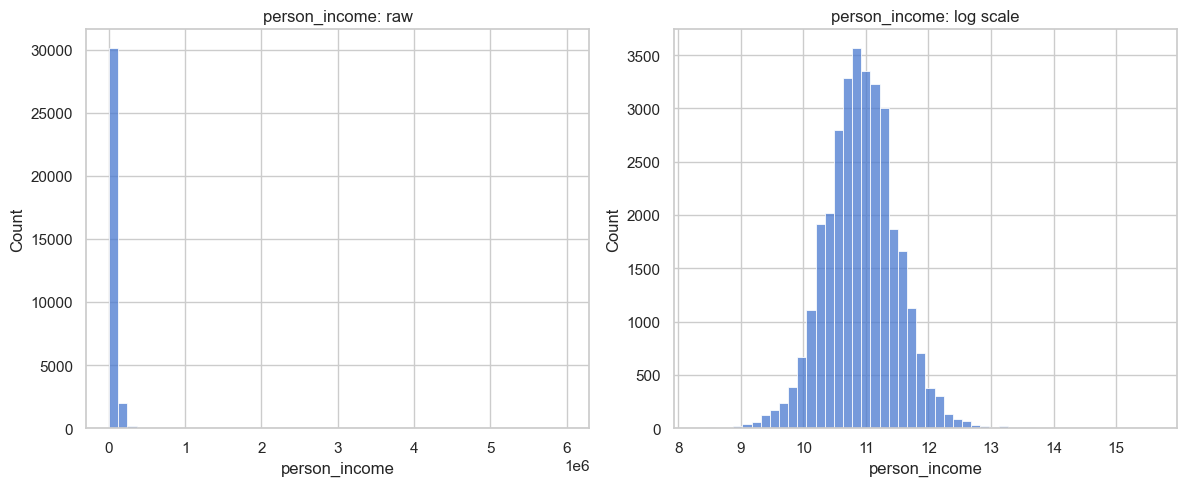

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["person_income"], bins=50, ax=axes[0])
axes[0].set_title("person_income: raw")

sns.histplot(np.log1p(df["person_income"]), bins=50, ax=axes[1])
axes[1].set_title("person_income: log scale")

plt.tight_layout()
plt.show()

## 8. Default rate by age group

We split applicants into `under_25` and `25_plus` and compare their default rates directly.


  age_group  loan_status
0   25_plus     0.209765
1  under_25     0.233432


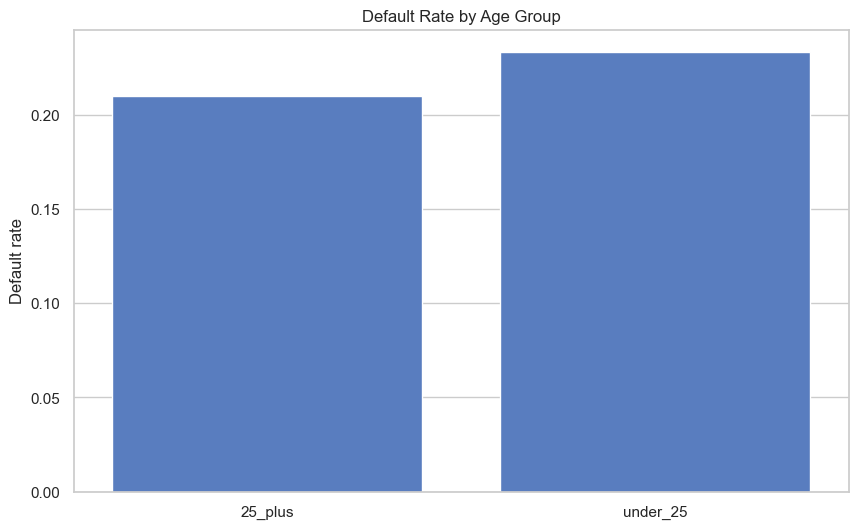

In [27]:
df["age_group"] = df["person_age"].apply(lambda a: "under_25" if a < 25 else "25_plus")

default_rate_by_age = df.groupby("age_group")["loan_status"].mean().reset_index()
print(default_rate_by_age)

ax = sns.barplot(data=default_rate_by_age, x="age_group", y="loan_status")
ax.set_title("Default Rate by Age Group")
ax.set_ylabel("Default rate")
ax.set_xlabel("")
plt.show()


## 9. Default rate by loan grade


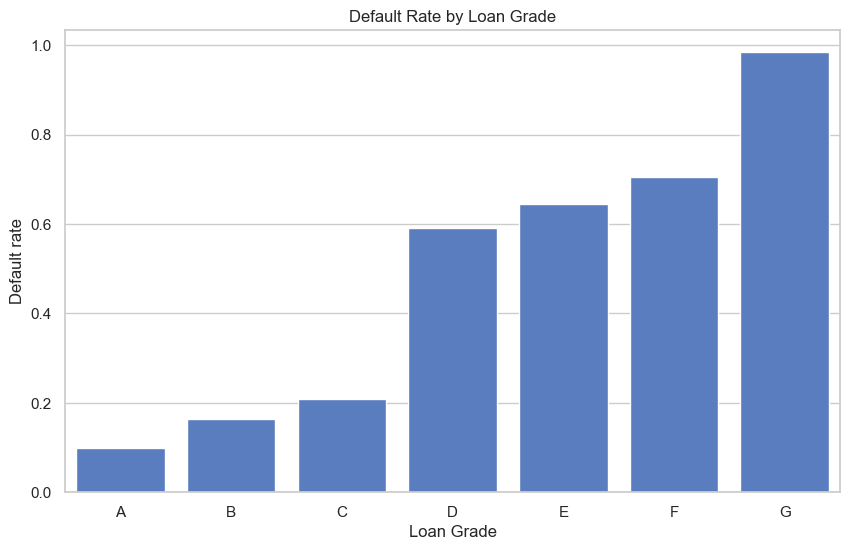

In [28]:
default_rate_by_grade = df.groupby("loan_grade")["loan_status"].mean().sort_index().reset_index()

ax = sns.barplot(data=default_rate_by_grade, x="loan_grade", y="loan_status", order=sorted(df["loan_grade"].unique()))
ax.set_title("Default Rate by Loan Grade")
ax.set_ylabel("Default rate")
ax.set_xlabel("Loan Grade")
plt.show()

## 10. `cb_person_default_on_file` and `cb_person_cred_hist_length`
- **`cb_person_default_on_file`** ("cb" = credit bureau): has this person defaulted before, according to their official credit history (Y/N). Past default behavior is usually one of the strongest predictors of future default.
- **`cb_person_cred_hist_length`**: how many years this person has had an active credit file. Longer history usually means a more established borrower.

  cb_person_default_on_file  loan_status
0                         N     0.184329
1                         Y     0.378709


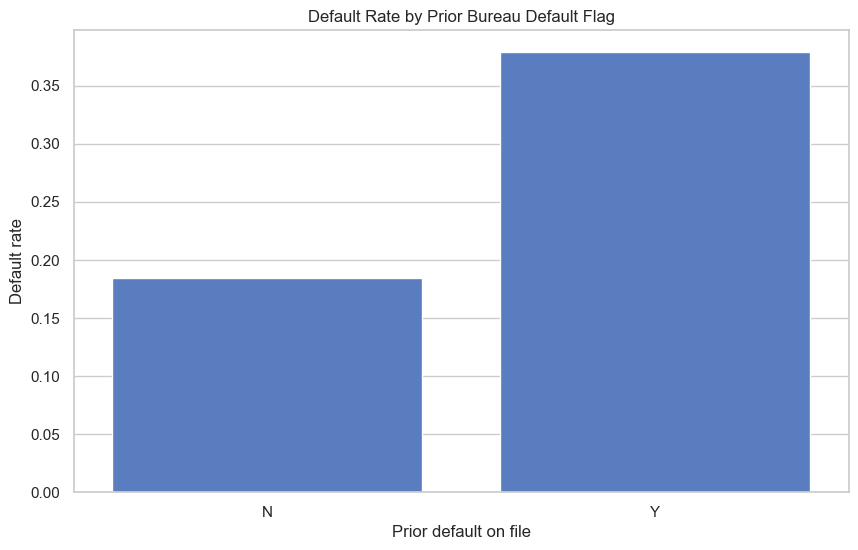

In [29]:
default_rate_by_bureau_flag = df.groupby("cb_person_default_on_file")["loan_status"].mean().reset_index()
print(default_rate_by_bureau_flag)

ax = sns.barplot(data=default_rate_by_bureau_flag, x="cb_person_default_on_file", y="loan_status")
ax.set_title("Default Rate by Prior Bureau Default Flag")
ax.set_ylabel("Default rate")
ax.set_xlabel("Prior default on file")
plt.show()

- `cb_person_cred_hist_length` naturally grows with age (you can't have 20 years of credit history at age 22). If it's strongly correlated with `person_age`, then even after we make the model "fair" with respect to age directly, age-based bias could sneak back in *through* this column. This is called a proxy variable, and it matters directly for the fairness/compliance goal of this project

Correlation between person_age and cb_person_cred_hist_length: 0.88


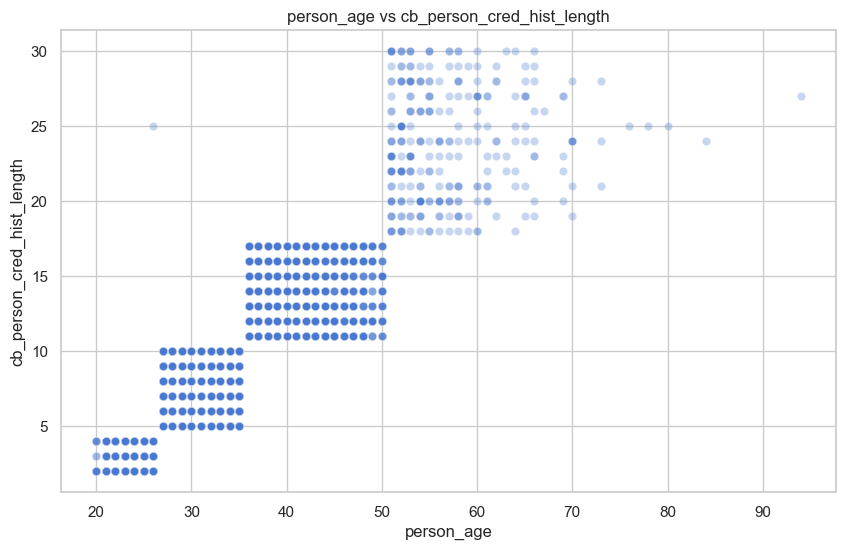

In [30]:
corr_age_credhist = df["person_age"].corr(df["cb_person_cred_hist_length"])
print(f"Correlation between person_age and cb_person_cred_hist_length: {corr_age_credhist:.2f}")

ax = sns.scatterplot(data=df, x="person_age", y="cb_person_cred_hist_length", alpha=0.3)
ax.set_title("person_age vs cb_person_cred_hist_length")
plt.show()

## 11. Correlation matrix (numeric features + target)

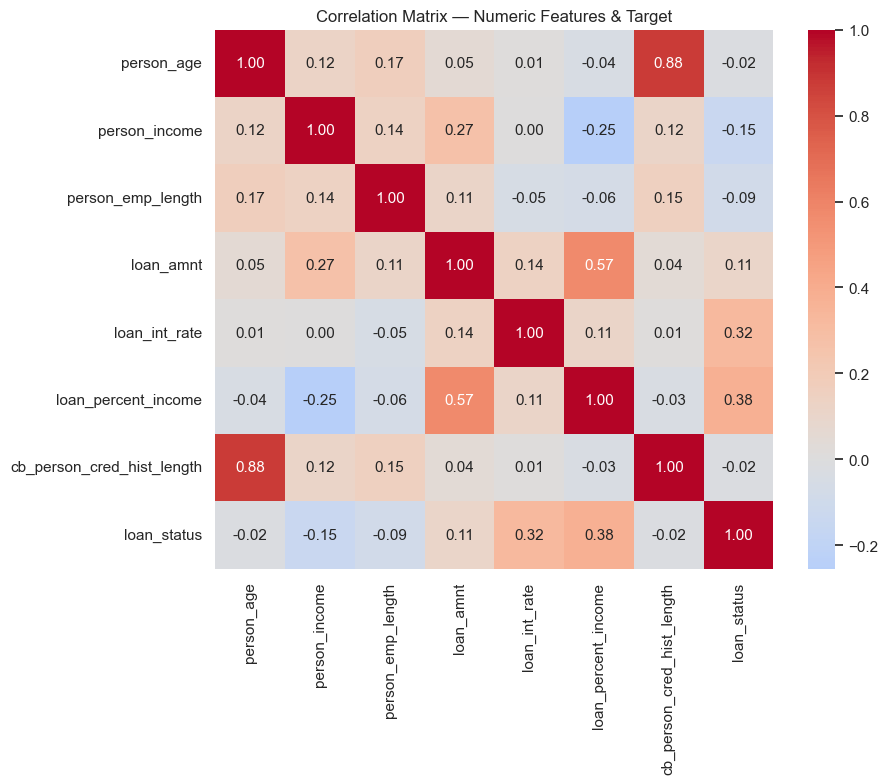

In [31]:
numeric_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt",
                "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length", "loan_status"]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Features & Target")
plt.show()


## 12. Summary
- 165 duplicate rows -> Dropped
- Missing `person_emp_length` (895) -> Filled with median
- Missing `loan_int_rate` (3,116) | Filled with median
- `person_age` > 100 -> Replaced with median (excl. outliers)
- `person_emp_length` > 60 -> Replaced with median (excl. outliers)
- `person_income` up to 600K+ -> Kept as-is since values are rare but genuinely possible; log-transformed only for plotting/modeling, never imputed or deleted

**Key finding):** `person_age` and `cb_person_cred_hist_length` show a [see printed correlation value above] correlation — worth flagging as a potential proxy-bias risk in the compliance write-up, since a model could reconstruct age bias through credit history length even if age itself is handled carefully.
